In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt






In [2]:
# 1. Cargar el mapa base (GeoJSON)
caba = gpd.read_file('datos/perimetro.geojson')

In [9]:
# 2. Cargar los CSVs
flujo_df = pd.read_csv('datos/flujo_vehicular.csv', sep=';')
siniestros_df = pd.read_csv('datos/siniestros_viales_hechos.csv', sep=';', low_memory=False)

In [10]:
# 3. Imprimir primer diagnóstico de columnas y tamaños
print(f"Límite CABA cargado. Sistema de coordenadas: {caba.crs}")
print(f"Filas en Flujo Vehicular: {len(flujo_df):,}")
print(f"Filas en Siniestros Viales: {len(siniestros_df):,}")

Límite CABA cargado. Sistema de coordenadas: EPSG:4326
Filas en Flujo Vehicular: 189,814
Filas en Siniestros Viales: 65,818


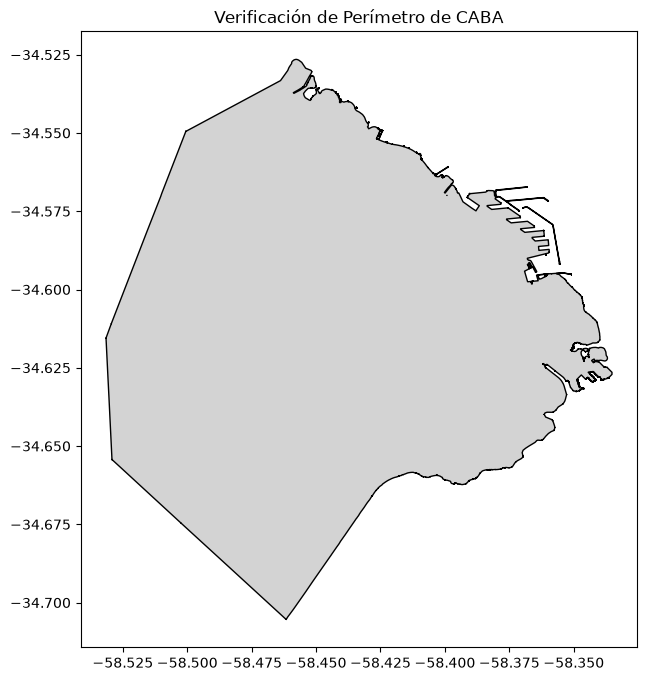

In [11]:


# 4. Graficar la base para verificar el GeoJSON
fig, ax = plt.subplots(figsize=(8, 8))
caba.plot(ax=ax, color='lightgray', edgecolor='black')
plt.title("Verificación de Perímetro de CABA", fontsize=12)
plt.show()

In [12]:
# Ver el nombre exacto de todas las columnas de cada dataset
print("--- COLUMNAS DE FLUJOS ---")
print(flujo_df.columns.tolist())

print("\n--- COLUMNAS DE SINIESTROS ---")
print(siniestros_df.columns.tolist())

# Ver las primeras 3 filas de siniestros para revisar las coordenadas
siniestros_df.head(3)

--- COLUMNAS DE FLUJOS ---
['CODIGO_LOCACION,HORA,CANTIDAD,SENTIDO,LATITUD,LONGITUD']

--- COLUMNAS DE SINIESTROS ---
['id_siniestro', 'numero_total_de_victimas', 'numero_victimas_leve_siniestro', 'numero_victimas_grave_siniestro', 'numero_victimas_mortal_siniestro', 'fecha_siniestro', 'anio_siniestro', 'mes_siniestro', 'dia_siniestro', 'hora_siniestro', 'rango_horario', 'direccion_normalizada_siniestro', 'comuna_siniestro', 'tipo_de_via_siniestro', 'geocodificacion_plana', 'longitud_siniestro', 'latitud_siniestro', 'participantes_siniestro', 'modo_desplazamiento_victima', 'contraparte_siniestro', 'gravedad_siniestro']


,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,...,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,gravedad_siniestro
0,LC-2019-0000053,1,1,0,0,2019-01-01,2019,1,1,01:55:00,...,NaN,Comuna 8,AUTOPISTA,POINT (101813.84712503915943671 95578.55507230...,-58.44351,-34.669125,AUTO-UTILITARIO,AUTO,UTILITARIO,LEVE
1,LC-2019-0000647,1,0,1,0,2019-01-01,2019,1,1,18:50:00,...,DE LOS CONSTITUYENTES AV. y HABANA,Comuna 12,AVENIDA,POINT (97510.27137648081406951 105087.83369881...,-58.490436,-34.583403,MOTO-AUTO,MOTO,AUTO,GRAVE
2,LC-2019-0000445,3,3,0,0,2019-01-01,2019,1,1,13:40:00,...,NaN,Comuna 11,NaN,POINT (94371.44237885093025398 102884.19365105...,-58.524662,-34.603255,AUTO-AUTO,AUTO,AUTO,LEVE


In [13]:
import geopandas as gpd
from shapely.geometry import Point

# 1. Eliminar filas que no tengan latitud o longitud
siniestros_clean = siniestros_df.dropna(subset=['longitud_siniestro', 'latitud_siniestro']).copy()

# 2. Asegurar que las columnas sean numéricas (por si vino algo como texto)
siniestros_clean['longitud_siniestro'] = pd.to_numeric(siniestros_clean['longitud_siniestro'], errors='coerce')
siniestros_clean['latitud_siniestro'] = pd.to_numeric(siniestros_clean['latitud_siniestro'], errors='coerce')

# Volver a limpiar por si algún string no se pudo convertir
siniestros_clean = siniestros_clean.dropna(subset=['longitud_siniestro', 'latitud_siniestro'])

# 3. Crear las geometrías (Puntos)
geometry = [Point(xy) for xy in zip(siniestros_clean['longitud_siniestro'], siniestros_clean['latitud_siniestro'])]

# 4. Crear el GeoDataFrame oficial
siniestros_gdf = gpd.GeoDataFrame(siniestros_clean, geometry=geometry, crs="EPSG:4326")

print(f"Siniestros convertidos a GeoDataFrame con éxito: {len(siniestros_gdf):,} puntos.")

Siniestros convertidos a GeoDataFrame con éxito: 62,787 puntos.


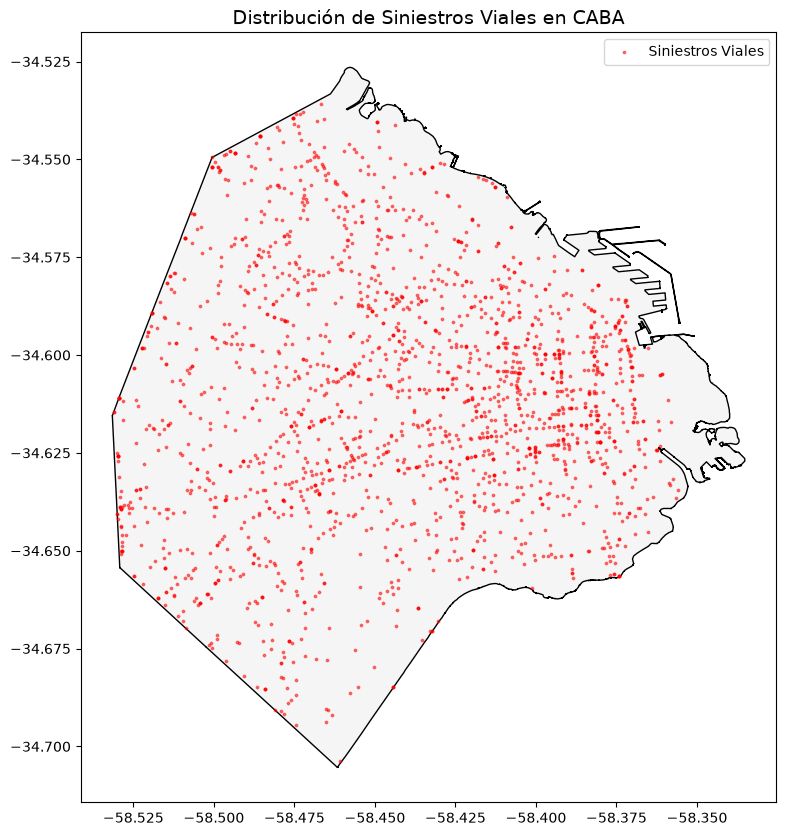

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Graficar mapa base de CABA
caba.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1)

# Graficar los primeros 2.000 siniestros para no saturar el mapa
siniestros_gdf.head(2000).plot(ax=ax, color='red', markersize=3, alpha=0.5, label='Siniestros Viales')

plt.title("Distribución de Siniestros Viales en CABA", fontsize=14)
plt.legend()
plt.show()